# Meta-Learner with IRM + SupCon + C-MMD — Causal/Invariant Learning

**Vấn đề**: Pipeline hiện tại (Meta_Learner.ipynb) chỉ dùng CrossEntropy loss → FeatureAligner học **shortcut/spurious correlations** (statistical signatures từng dataset) thay vì **causal attack behavior**. Kết quả: zero-shot transfer luôn thất bại (IoT F1=0.55, WUSTL F1=0.14).

**Giải pháp Phase 1 (IRM+MMD)**: Cải thiện F1 tổng 1 xíu nhưng BruteForce/DoS vẫn 0%, Infiltration precision chỉ 16%.

**Giải pháp Phase 2 (hiện tại)**: Thêm **SupCon** + **Class-Conditional MMD** để fix per-class failures:

$$L_{total} = \frac{L_{CE}^{UQ} + L_{CE}^{CIC}}{2} + \lambda_{IRM} \cdot \frac{P_{IRM}^{UQ} + P_{IRM}^{CIC}}{2} + \lambda_{SC} \cdot L_{SupCon}(z_{all}, y_{all}) + \lambda_{CMMD} \cdot \text{C-MMD}(z_{UQ}, z_{CIC})$$

- **IRM penalty**: Phạt model nếu classifier không optimal trên MỌI environment → buộc dùng invariant features
- **SupCon loss**: Kéo Z cùng class lại gần, đẩy khác class ra xa — kể cả cross-domain → fix BruteForce/DoS = 0%
- **C-MMD loss**: Align per-class distributions (thay global MMD) → fix Infiltration over-prediction
- **λ_irm annealing**: Warmup 5 epochs (pure ERM) → tăng tuyến tính đến λ_max

**Files**:
- `feature_alignment.py` — components gốc (reused)
- `feature_alignment_irm.py` — IRM, SupCon, C-MMD, PairedEnvironmentLoader
- Models saved to `../Project/Model/Model_2017_IRM/`

In [6]:
import sys, os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from copy import deepcopy
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))

# Original feature alignment components
from feature_alignment import (
    prepare_combined_dataset, FeatureAligner, create_dataloaders,
    TimeSeriesDataset,
    DEVICE, LATENT_DIM, WINDOW_SIZE, NUM_CLASSES, UNIFIED_CLASSES
)

# IRM + SupCon + C-MMD extensions
from feature_alignment_irm import (
    compute_irm_penalty, gaussian_kernel, mmd_loss,
    supervised_contrastive_loss, class_conditional_mmd,
    PairedEnvironmentLoader, train_base_model_irm,
)

print(f"Device: {DEVICE}")
print(f"Latent Dim: {LATENT_DIM}, Window Size: {WINDOW_SIZE}")
print(f"Classes: {UNIFIED_CLASSES}")

Device: cuda
Latent Dim: 64, Window Size: 30
Classes: ['Benign', 'BruteForce', 'DDoS', 'DoS', 'Infiltration']


## 1. Load Combined Dataset

Cùng data pipeline như Meta_Learner.ipynb — load UQ (47 features) + CIC-2017 (78 features).

In [7]:
%%time
# Load combined dataset
data = prepare_combined_dataset()

uq_windows = data['uq']['windows']     # (N_uq, 30, 47)
uq_labels = data['uq']['labels']       # (N_uq,)
cic_windows = data['cic']['windows']    # (N_cic, 30, 78)
cic_labels = data['cic']['labels']      # (N_cic,)

uq_n_feat = data['uq']['n_features']   # 47
cic_n_feat = data['cic']['n_features']  # 78

print(f"UQ: {uq_windows.shape}, CIC: {cic_windows.shape}")
print(f"Classes: {data['classes']}")

[UQ] Loaded 1388150 flows, 47 features
[UQ] Label distribution:
Label
Benign          399999
DoS             300000
DDoS            300000
BruteForce      199999
Infiltration    188152
[UQ] Created 186005 windows of shape (186005, 30, 47)
[UQ] Feature dim: 47, Latent target: 64
[CIC] Loaded 237618 flows, 78 features
[CIC] Label distribution:
Label
Benign          100000
DoS              71588
DDoS             50000
BruteForce       15994
Infiltration        36
[CIC] Created 101615 windows of shape (101615, 30, 78)
[CIC] Feature dim: 78, Latent target: 64

=== Combined Dataset ===
UQ: 186005 windows, 47 features
CIC: 101615 windows, 78 features
Total: 287620 windows
UQ: (186005, 30, 47), CIC: (101615, 30, 78)
Classes: ['Benign', 'BruteForce', 'DDoS', 'DoS', 'Infiltration']
CPU times: user 35.7 s, sys: 3.6 s, total: 39.3 s
Wall time: 37.4 s


## 2. Define Model Architectures

Kiến trúc 100% giống Meta_Learner.ipynb — chỉ training loop thay đổi.

In [8]:
# ================================================================
# Model Architectures (identical to Meta_Learner.ipynb)
# ================================================================

class CNN_LSTM(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM, num_classes=NUM_CLASSES):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(latent_dim, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.2),
            nn.Conv1d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.2),
            nn.Conv1d(128, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64), nn.ReLU(),
        )
        self.lstm = nn.LSTM(64, 128, num_layers=2, batch_first=True, dropout=0.3)
        self.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(128, num_classes))

    def forward(self, z):
        x = z.permute(0, 2, 1)
        x = self.cnn(x).permute(0, 2, 1)
        _, (h_n, _) = self.lstm(x)
        return self.classifier(h_n[-1])


class TemporalAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2), nn.Tanh(),
            nn.Linear(hidden_dim // 2, 1),
        )

    def forward(self, lstm_output):
        attn_weights = torch.softmax(self.attention(lstm_output), dim=1)
        return (lstm_output * attn_weights).sum(dim=1), attn_weights.squeeze(-1)


class TL_BiLSTM(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM, hidden_dim=128, num_classes=NUM_CLASSES):
        super().__init__()
        self.bilstm = nn.LSTM(latent_dim, hidden_dim // 2, num_layers=2,
                              batch_first=True, dropout=0.3, bidirectional=True)
        self.attention = TemporalAttention(hidden_dim)
        self.layer_norm = nn.LayerNorm(hidden_dim)
        self.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(hidden_dim, num_classes))

    def forward(self, z):
        lstm_out, _ = self.bilstm(z)
        context, _ = self.attention(lstm_out)
        return self.classifier(self.layer_norm(context))


class TransformerClassifier(nn.Module):
    def __init__(self, d_model=LATENT_DIM, nhead=8, num_layers=4,
                 dim_feedforward=256, num_classes=NUM_CLASSES):
        super().__init__()
        self.pos_enc = nn.Parameter(torch.randn(1, WINDOW_SIZE, d_model) * 0.02)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
            dropout=0.1, batch_first=True, activation='gelu')
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.layer_norm = nn.LayerNorm(d_model)
        self.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(d_model, num_classes))

    def forward(self, z):
        x = z + self.pos_enc[:, :z.size(1), :]
        x = self.layer_norm(self.transformer(x))
        return self.classifier(x.mean(dim=1))


class AlignerWithModel(nn.Module):
    def __init__(self, uq_dim, cic_dim, base_model):
        super().__init__()
        self.aligner = FeatureAligner(uq_dim, cic_dim)
        self.base_model = base_model

    def forward(self, x, dataset_type='uq'):
        z = self.aligner(x, dataset_type)
        return self.base_model(z)

    def predict_proba(self, x, dataset_type='uq'):
        return torch.softmax(self.forward(x, dataset_type), dim=1)


def create_models(uq_dim, cic_dim):
    return {
        'cnn_lstm': AlignerWithModel(uq_dim, cic_dim, CNN_LSTM()),
        'tl_bilstm': AlignerWithModel(uq_dim, cic_dim, TL_BiLSTM()),
        'transformer': AlignerWithModel(uq_dim, cic_dim, TransformerClassifier()),
    }


# Verify
models = create_models(uq_n_feat, cic_n_feat)
for name, m in models.items():
    params = sum(p.numel() for p in m.parameters())
    print(f"{name}: {params:,} params")
del models

cnn_lstm: 364,869 params
tl_bilstm: 208,646 params
transformer: 235,845 params


## 3. Hyperparameters & Training Utilities

**Thay đổi so với Meta_Learner.ipynb:**
- `train_base_model_irm()` thay thế `train_base_model()` — forward cả UQ + CIC đồng thời
- IRM penalty + SupCon + C-MMD bổ sung vào CrossEntropy
- λ_irm annealing: 5 epochs pure ERM → ramp tuyến tính đến λ_max=10.0

**Bảng so sánh**:
| | Meta_Learner.ipynb | Phase 1 (IRM) | Phase 2 (hiện tại) |
|---|---|---|---|
| Loss | CE only | CE + IRM + global MMD | CE + IRM + SupCon + C-MMD |
| Batch strategy | Interleave UQ/CIC | Paired (đồng thời) | Paired (đồng thời) |
| Class separation | Implicit (CE only) | Implicit (CE only) | **Explicit (SupCon)** |
| Latent alignment | None | Global MMD | **Per-class MMD (C-MMD)** |
| Feature invariance | None | IRM penalty | IRM penalty |
| Epochs | 30 | 50 (thêm warmup) | 50 (thêm warmup) |

In [9]:
from torch.utils.data import DataLoader

# ================================================================
# Hyperparameters
# ================================================================
BATCH_SIZE = 256
BASE_EPOCHS = 50          # increased from 30 to accommodate IRM warmup
PATIENCE = 5
K = 2                     # K-Fold
MODEL_NAMES = ['cnn_lstm', 'tl_bilstm', 'transformer']

# IRM specific
LAMBDA_IRM_MAX = 10.0     # max IRM penalty weight (after warmup)
WARMUP_EPOCHS = 5         # pure ERM before IRM kicks in

# SupCon + C-MMD specific (Phase 2 — fix BruteForce/DoS=0%, Infiltration precision=16%)
LAMBDA_SUPCON = 0.1       # SupCon loss weight (small — SupCon gradient scale is large)
LAMBDA_CMMD = 0.5         # Class-Conditional MMD weight
SUPCON_TEMPERATURE = 0.1  # SupCon temperature τ (standard Khosla 2020)
MMD_SUBSAMPLE = 1024      # subsample for kernel matrix memory

# Global MMD (Phase 1 — disabled, replaced by C-MMD)
LAMBDA_MMD = 0.0

# Model save directory
MODEL_DIR = os.path.join('..', 'Project', 'Model', 'Model_IRM')
os.makedirs(MODEL_DIR, exist_ok=True)

print("=== IRM + SupCon + C-MMD Training Hyperparameters ===")
print(f"  Epochs: {BASE_EPOCHS} (warmup: {WARMUP_EPOCHS})")
print(f"  λ_irm_max: {LAMBDA_IRM_MAX}")
print(f"  λ_supcon: {LAMBDA_SUPCON} (τ={SUPCON_TEMPERATURE})")
print(f"  λ_cmmd: {LAMBDA_CMMD}")
print(f"  λ_mmd (global, disabled): {LAMBDA_MMD}")
print(f"  MMD subsample: {MMD_SUBSAMPLE}")
print(f"  K-Folds: {K}")
print(f"  Save dir: {MODEL_DIR}")


@torch.no_grad()
def predict_proba_dataset(model, windows, dataset_type, batch_size=512):
    """Get softmax probabilities for a dataset."""
    model.eval()
    ds = TimeSeriesDataset(windows, np.zeros(len(windows)), dataset_type)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)
    all_probs = []
    for x, _, _ in loader:
        x = x.to(DEVICE)
        probs = torch.softmax(model(x, dataset_type), dim=1)
        all_probs.append(probs.cpu().numpy())
    return np.vstack(all_probs)


print("\n✓ Training utilities defined.")

=== IRM + SupCon + C-MMD Training Hyperparameters ===
  Epochs: 50 (warmup: 5)
  λ_irm_max: 10.0
  λ_supcon: 0.1 (τ=0.1)
  λ_cmmd: 0.5
  λ_mmd (global, disabled): 0.0
  MMD subsample: 1024
  K-Folds: 2
  Save dir: ../Project/Model/Model_IRM

✓ Training utilities defined.


## 4. K-Fold OOF Training with IRM + SupCon + C-MMD

**Quy trình** (giống Meta_Learner.ipynb nhưng dùng `train_base_model_irm` với SupCon + C-MMD):

1. Cho mỗi fold k (1..K):
   - Chia UQ và CIC thành train/val (StratifiedKFold riêng)
   - Train 3 base models với IRM + SupCon + C-MMD loss
   - Generate OOF predictions trên validation fold
   
2. Kết quả: Mỗi sample có predictions từ model chưa bao giờ nhìn thấy nó

**SupCon hoạt động ở đây**: Mỗi training step, Z vectors từ CẢ UQ và CIC được gộp lại → SupCon kéo BruteForce_UQ gần BruteForce_CIC, đẩy xa Benign_CIC. Điều này ép buộc BruteForce/DoS tạo cluster riêng trong Z space thay vì bị nuốt vào vùng Benign.

**C-MMD hoạt động ở đây**: Thay vì align toàn bộ phân phối (Benign chiếm 80% → dominate alignment), C-MMD align từng class riêng → DDoS_UQ gần DDoS_CIC, Infiltration_UQ gần Infiltration_CIC.

In [10]:
# ================================================================
# K-Fold OOF Setup
# ================================================================

# Initialize OOF arrays
uq_oof = {name: np.zeros((len(uq_labels), NUM_CLASSES)) for name in MODEL_NAMES}
cic_oof = {name: np.zeros((len(cic_labels), NUM_CLASSES)) for name in MODEL_NAMES}

skf_uq = StratifiedKFold(n_splits=K, shuffle=True, random_state=42)
skf_cic = StratifiedKFold(n_splits=K, shuffle=True, random_state=42)

uq_folds = list(skf_uq.split(uq_windows, uq_labels))
cic_folds = list(skf_cic.split(cic_windows, cic_labels))

# Store training histories for analysis
fold_histories = {name: [] for name in MODEL_NAMES}

print(f"K-Fold OOF: {K} folds, {len(MODEL_NAMES)} models")
print(f"UQ: {len(uq_labels)} samples, CIC: {len(cic_labels)} samples")
print(f"Total training runs: {K} folds × {len(MODEL_NAMES)} models = {K * len(MODEL_NAMES)}")

K-Fold OOF: 2 folds, 3 models
UQ: 186005 samples, CIC: 101615 samples
Total training runs: 2 folds × 3 models = 6


In [11]:
%%time
# ================================================================
# K-Fold OOF Training Loop (IRM + SupCon + C-MMD)
# ================================================================

for fold_idx in range(K):
    print(f"\n{'='*60}")
    print(f"FOLD {fold_idx + 1}/{K}")
    print(f"{'='*60}")

    # Get fold indices
    uq_train_idx, uq_val_idx = uq_folds[fold_idx]
    cic_train_idx, cic_val_idx = cic_folds[fold_idx]

    # Split data for this fold
    uq_train_X, uq_val_X = uq_windows[uq_train_idx], uq_windows[uq_val_idx]
    uq_train_y, uq_val_y = uq_labels[uq_train_idx], uq_labels[uq_val_idx]
    cic_train_X, cic_val_X = cic_windows[cic_train_idx], cic_windows[cic_val_idx]
    cic_train_y, cic_val_y = cic_labels[cic_train_idx], cic_labels[cic_val_idx]

    print(f"UQ  train: {len(uq_train_X)}, val: {len(uq_val_X)}")
    print(f"CIC train: {len(cic_train_X)}, val: {len(cic_val_X)}")

    # Train each base model with IRM + SupCon + C-MMD
    for model_name in MODEL_NAMES:
        print(f"\n--- Training {model_name} (Fold {fold_idx+1}) with IRM+SupCon+C-MMD ---")

        # Create fresh model
        models = create_models(uq_n_feat, cic_n_feat)
        model = models[model_name]

        # Train with IRM + SupCon + C-MMD
        model, best_loss, history = train_base_model_irm(
            model,
            uq_train_X, uq_train_y, cic_train_X, cic_train_y,
            uq_val_X, uq_val_y, cic_val_X, cic_val_y,
            epochs=BASE_EPOCHS,
            lr=1e-3,
            batch_size=BATCH_SIZE,
            lambda_irm_max=LAMBDA_IRM_MAX,
            lambda_mmd=LAMBDA_MMD,
            lambda_supcon=LAMBDA_SUPCON,
            lambda_cmmd=LAMBDA_CMMD,
            supcon_temperature=SUPCON_TEMPERATURE,
            warmup_epochs=WARMUP_EPOCHS,
            mmd_subsample=MMD_SUBSAMPLE,
            patience=PATIENCE,
            verbose=True,
        )
        print(f"  Best val loss: {best_loss:.4f}")

        # Store history
        fold_histories[model_name].append(history)

        # Predict OOF probabilities on validation fold
        uq_probs = predict_proba_dataset(model, uq_val_X, 'uq')
        cic_probs = predict_proba_dataset(model, cic_val_X, 'cic')

        # Store OOF predictions
        uq_oof[model_name][uq_val_idx] = uq_probs
        cic_oof[model_name][cic_val_idx] = cic_probs

        # Quick accuracy check
        uq_acc = (uq_probs.argmax(1) == uq_val_y).mean()
        cic_acc = (cic_probs.argmax(1) == cic_val_y).mean()
        print(f"  OOF Acc — UQ: {uq_acc:.4f}, CIC: {cic_acc:.4f}")

        # Free GPU memory
        del model, models
        torch.cuda.empty_cache()

print(f"\n{'='*60}")
print("K-Fold OOF complete!")
print(f"{'='*60}")


FOLD 1/2
UQ  train: 93002, val: 93003
CIC train: 50807, val: 50808

--- Training cnn_lstm (Fold 1) with IRM+SupCon+C-MMD ---
  Epoch   5 | CE: 0.1013 | IRM: 0.0000 | SC: 0.5337 | CMMD: 0.0221 | Val: 0.2724 | λ_irm: 0.00 | P: 2/5
  Epoch   8 | CE: 0.0821 | IRM: 0.0004 | SC: 0.5295 | CMMD: 0.0167 | Val: 0.1961 | λ_irm: 0.44 | P: 5/5
  Early stopping at epoch 8
  Best val loss: 0.1341
  OOF Acc — UQ: 0.9312, CIC: 0.9823

--- Training tl_bilstm (Fold 1) with IRM+SupCon+C-MMD ---
  Epoch   5 | CE: 0.0817 | IRM: 0.0000 | SC: 0.5321 | CMMD: 0.0239 | Val: 0.1037 | λ_irm: 0.00 | P: 0/5
  Epoch  10 | CE: 0.0687 | IRM: 0.0004 | SC: 0.5282 | CMMD: 0.0197 | Val: 0.0937 | λ_irm: 0.89 | P: 0/5
  Epoch  15 | CE: 0.0664 | IRM: 0.0009 | SC: 0.5269 | CMMD: 0.0178 | Val: 0.0912 | λ_irm: 2.00 | P: 3/5
  Epoch  20 | CE: 0.0630 | IRM: 0.0012 | SC: 0.5259 | CMMD: 0.0161 | Val: 0.2018 | λ_irm: 3.11 | P: 2/5
  Epoch  25 | CE: 0.0608 | IRM: 0.0012 | SC: 0.5254 | CMMD: 0.0156 | Val: 0.1586 | λ_irm: 4.22 | P: 3/5

## 5. Training Diagnostics (IRM + SupCon + C-MMD)

Phân tích training dynamics:
- **CE loss**: Classification loss — nên giảm dần
- **IRM penalty**: Nên giảm → model đang học invariant features
- **SupCon loss**: Nên giảm → same-class Z getting closer, different-class Z pushed apart
- **C-MMD loss**: Nên giảm → per-class distributions aligning across domains
- **Val loss**: Validation CE — nên giảm và converge

⚠️ Nếu SupCon không giảm → `λ_supcon` quá nhỏ hoặc `τ` cần điều chỉnh
⚠️ Nếu C-MMD = 0 ở nhiều epochs → class overlap giữa UQ/CIC quá ít, cần kiểm tra data

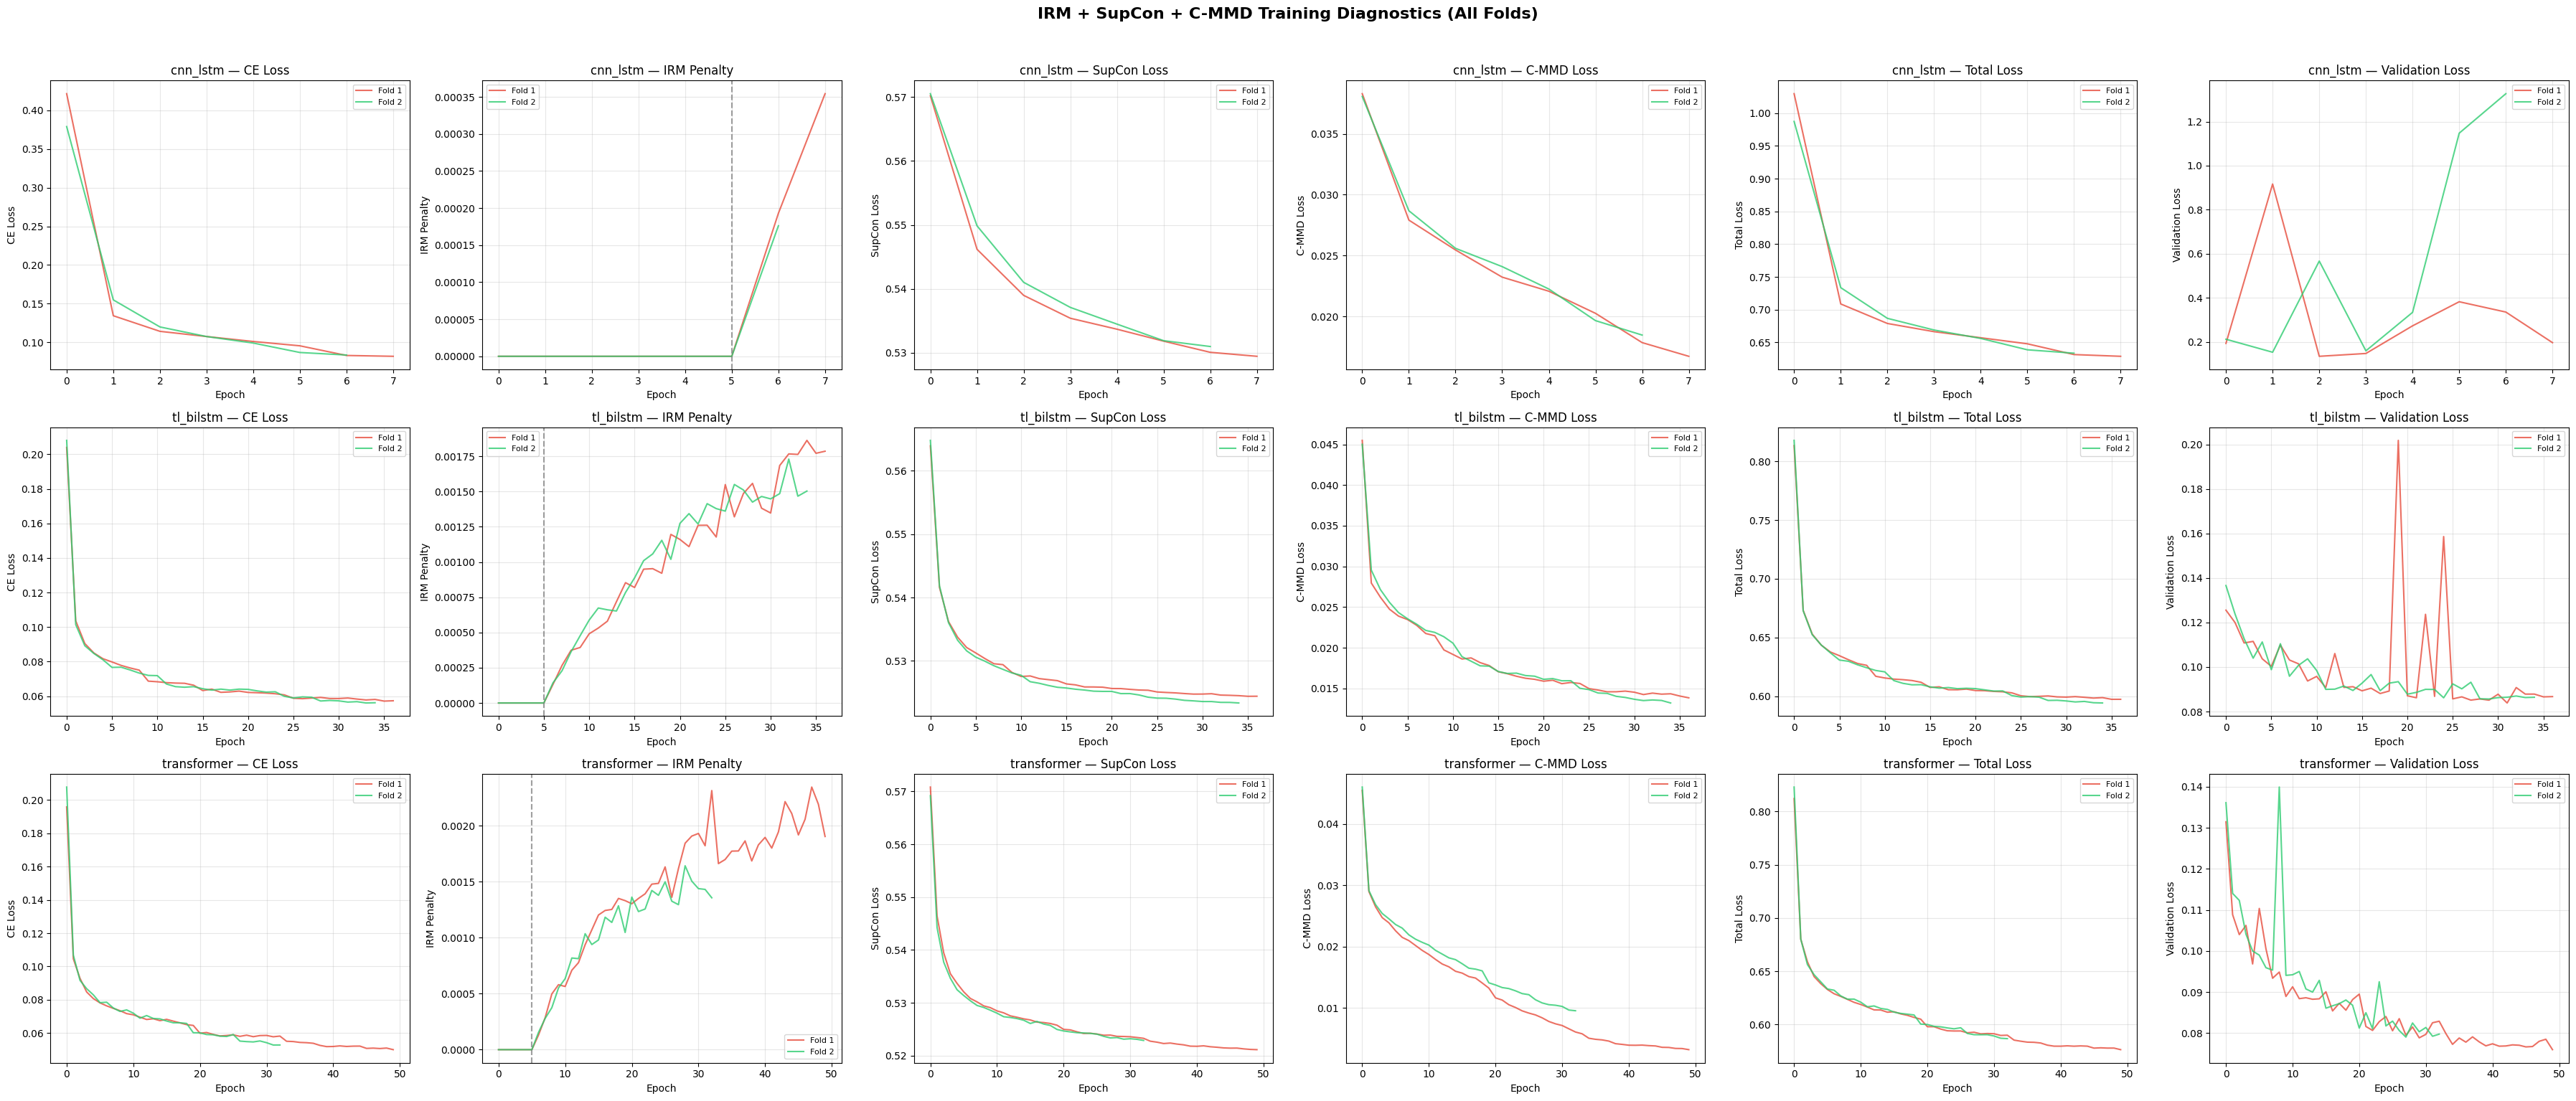

✓ Training diagnostics saved.


In [12]:
# ================================================================
# Plot Training Diagnostics (IRM + SupCon + C-MMD)
# ================================================================

fig, axes = plt.subplots(len(MODEL_NAMES), 6, figsize=(36, 5 * len(MODEL_NAMES)))
if len(MODEL_NAMES) == 1:
    axes = axes[np.newaxis, :]

loss_keys = ['ce', 'irm', 'supcon', 'cmmd', 'total', 'val_loss']
loss_titles = ['CE Loss', 'IRM Penalty', 'SupCon Loss', 'C-MMD Loss', 'Total Loss', 'Validation Loss']
colors_fold = ['#e74c3c', '#2ecc71', '#3498db', '#9b59b6']

for row, model_name in enumerate(MODEL_NAMES):
    for col, (key, title) in enumerate(zip(loss_keys, loss_titles)):
        ax = axes[row, col]
        for fold_idx, hist in enumerate(fold_histories[model_name]):
            values = hist.get(key, [])
            if len(values) == 0:
                continue
            ax.plot(values, label=f'Fold {fold_idx+1}', color=colors_fold[fold_idx], alpha=0.8)

            # Mark warmup boundary for IRM
            if key in ('irm',) and WARMUP_EPOCHS < len(values):
                ax.axvline(x=WARMUP_EPOCHS, color='gray', linestyle='--', alpha=0.5)

        ax.set_xlabel('Epoch')
        ax.set_ylabel(title)
        ax.set_title(f'{model_name} — {title}')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

plt.suptitle('IRM + SupCon + C-MMD Training Diagnostics (All Folds)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print("✓ Training diagnostics saved.")

## 6. Assemble Meta-Dataset & Train Meta-Learner

Stack OOF predictions → X_meta (N, 15) → LogisticRegression.  
Quy trình giống hệt Meta_Learner.ipynb — chỉ chất lượng OOF predictions khác (vì trained with IRM+MMD).

In [13]:
# ================================================================
# Assemble Meta-Dataset from OOF Predictions
# ================================================================

uq_meta_parts = [uq_oof[name] for name in MODEL_NAMES]
cic_meta_parts = [cic_oof[name] for name in MODEL_NAMES]

uq_X_meta = np.hstack(uq_meta_parts)   # (N_uq, 15)
cic_X_meta = np.hstack(cic_meta_parts)  # (N_cic, 15)

X_meta = np.vstack([uq_X_meta, cic_X_meta])
y_meta = np.concatenate([uq_labels, cic_labels])
dataset_origin = np.array(['uq'] * len(uq_labels) + ['cic'] * len(cic_labels))

print(f"Meta-Dataset: X_meta {X_meta.shape}, y_meta {y_meta.shape}")
print(f"Feature breakdown: {len(MODEL_NAMES)} models × {NUM_CLASSES} classes = {X_meta.shape[1]} features")

print(f"\nPer-model OOF accuracy (IRM-trained):")
for i, name in enumerate(MODEL_NAMES):
    preds = X_meta[:, i*NUM_CLASSES:(i+1)*NUM_CLASSES].argmax(1)
    acc = (preds == y_meta).mean()
    f1 = f1_score(y_meta, preds, average='weighted')
    print(f"  {name}: Acc={acc:.4f}, Weighted-F1={f1:.4f}")

# Save meta-dataset
np.savez(os.path.join(MODEL_DIR, 'meta_dataset.npz'),
         X_meta=X_meta, y_meta=y_meta, dataset_origin=dataset_origin)
print("\n✓ Meta-dataset saved.")

Meta-Dataset: X_meta (287620, 15), y_meta (287620,)
Feature breakdown: 3 models × 5 classes = 15 features

Per-model OOF accuracy (IRM-trained):
  cnn_lstm: Acc=0.9388, Weighted-F1=0.9408
  tl_bilstm: Acc=0.9532, Weighted-F1=0.9550
  transformer: Acc=0.9559, Weighted-F1=0.9577

✓ Meta-dataset saved.


In [14]:
from sklearn.model_selection import train_test_split
import joblib

# ================================================================
# Train Meta-Learner (same as Meta_Learner.ipynb)
# ================================================================

X_train_meta, X_test_meta, y_train_meta, y_test_meta, origin_train, origin_test = \
    train_test_split(X_meta, y_meta, dataset_origin,
                     test_size=0.2, random_state=42, stratify=y_meta)

print(f"Meta Train: {X_train_meta.shape}, Meta Test: {X_test_meta.shape}")

# === Option A: Logistic Regression ===
print("\n=== Option A: Logistic Regression ===\n")
lr_meta = LogisticRegression(
    multi_class='multinomial', solver='lbfgs',
    C=1.0, max_iter=1000, random_state=42,
)
lr_meta.fit(X_train_meta, y_train_meta)

lr_preds = lr_meta.predict(X_test_meta)
lr_f1 = f1_score(y_test_meta, lr_preds, average='weighted')
print(f"Logistic Regression weighted F1: {lr_f1:.4f}")
print(classification_report(y_test_meta, lr_preds,
                            target_names=UNIFIED_CLASSES, digits=4))

# === Option B: Dense NN ===
print("\n=== Option B: Dense NN (1 layer) ===\n")

class DenseMetaLearner(nn.Module):
    def __init__(self, input_dim=15, num_classes=NUM_CLASSES):
        super().__init__()
        self.fc = nn.Linear(input_dim, num_classes)

    def forward(self, x):
        return self.fc(x)

dense_meta = DenseMetaLearner(X_meta.shape[1]).to(DEVICE)
meta_criterion = nn.CrossEntropyLoss()
meta_optimizer = optim.Adam(dense_meta.parameters(), lr=1e-2)

X_train_t = torch.FloatTensor(X_train_meta).to(DEVICE)
y_train_t = torch.LongTensor(y_train_meta).to(DEVICE)
X_test_t = torch.FloatTensor(X_test_meta).to(DEVICE)

for epoch in range(200):
    dense_meta.train()
    meta_optimizer.zero_grad()
    logits = dense_meta(X_train_t)
    loss = meta_criterion(logits, y_train_t)
    loss.backward()
    meta_optimizer.step()

dense_meta.eval()
with torch.no_grad():
    nn_preds = dense_meta(X_test_t).argmax(1).cpu().numpy()

nn_f1 = f1_score(y_test_meta, nn_preds, average='weighted')
print(f"Dense NN weighted F1: {nn_f1:.4f}")
print(classification_report(y_test_meta, nn_preds,
                            target_names=UNIFIED_CLASSES, digits=4))

# === Select best ===
if lr_f1 >= nn_f1:
    print(f"\n✓ Best Meta-Learner: Logistic Regression (F1={lr_f1:.4f})")
    best_meta = 'logistic_regression'
    final_preds = lr_preds
    joblib.dump(lr_meta, os.path.join(MODEL_DIR, 'meta_learner_lr.pkl'))
else:
    print(f"\n✓ Best Meta-Learner: Dense NN (F1={nn_f1:.4f})")
    best_meta = 'dense_nn'
    final_preds = nn_preds
    torch.save(dense_meta.state_dict(), os.path.join(MODEL_DIR, 'meta_learner_nn.pth'))

print("✓ Meta-Learner saved.")

Meta Train: (230096, 15), Meta Test: (57524, 15)

=== Option A: Logistic Regression ===

Logistic Regression weighted F1: 0.9725
              precision    recall  f1-score   support

      Benign     0.9806    0.9789    0.9797     32254
  BruteForce     0.9654    0.9919    0.9784      6660
        DDoS     0.9969    0.9982    0.9975      7736
         DoS     0.9897    0.9541    0.9716      4948
Infiltration     0.8912    0.8974    0.8943      5926

    accuracy                         0.9725     57524
   macro avg     0.9648    0.9641    0.9643     57524
weighted avg     0.9726    0.9725    0.9725     57524


=== Option B: Dense NN (1 layer) ===

Dense NN weighted F1: 0.9720
              precision    recall  f1-score   support

      Benign     0.9814    0.9775    0.9795     32254
  BruteForce     0.9654    0.9917    0.9784      6660
        DDoS     0.9956    0.9972    0.9964      7736
         DoS     0.9862    0.9529    0.9693      4948
Infiltration     0.8867    0.9021    0.8944

## 7. Meta-Learner Evaluation Dashboard

So sánh performance:
- Per-dataset breakdown: UQ vs CIC (SupCon+C-MMD nên giảm gap giữa 2 domains)
- Per-class F1 comparison (BruteForce/DoS nên > 0%, Infiltration precision nên cải thiện)

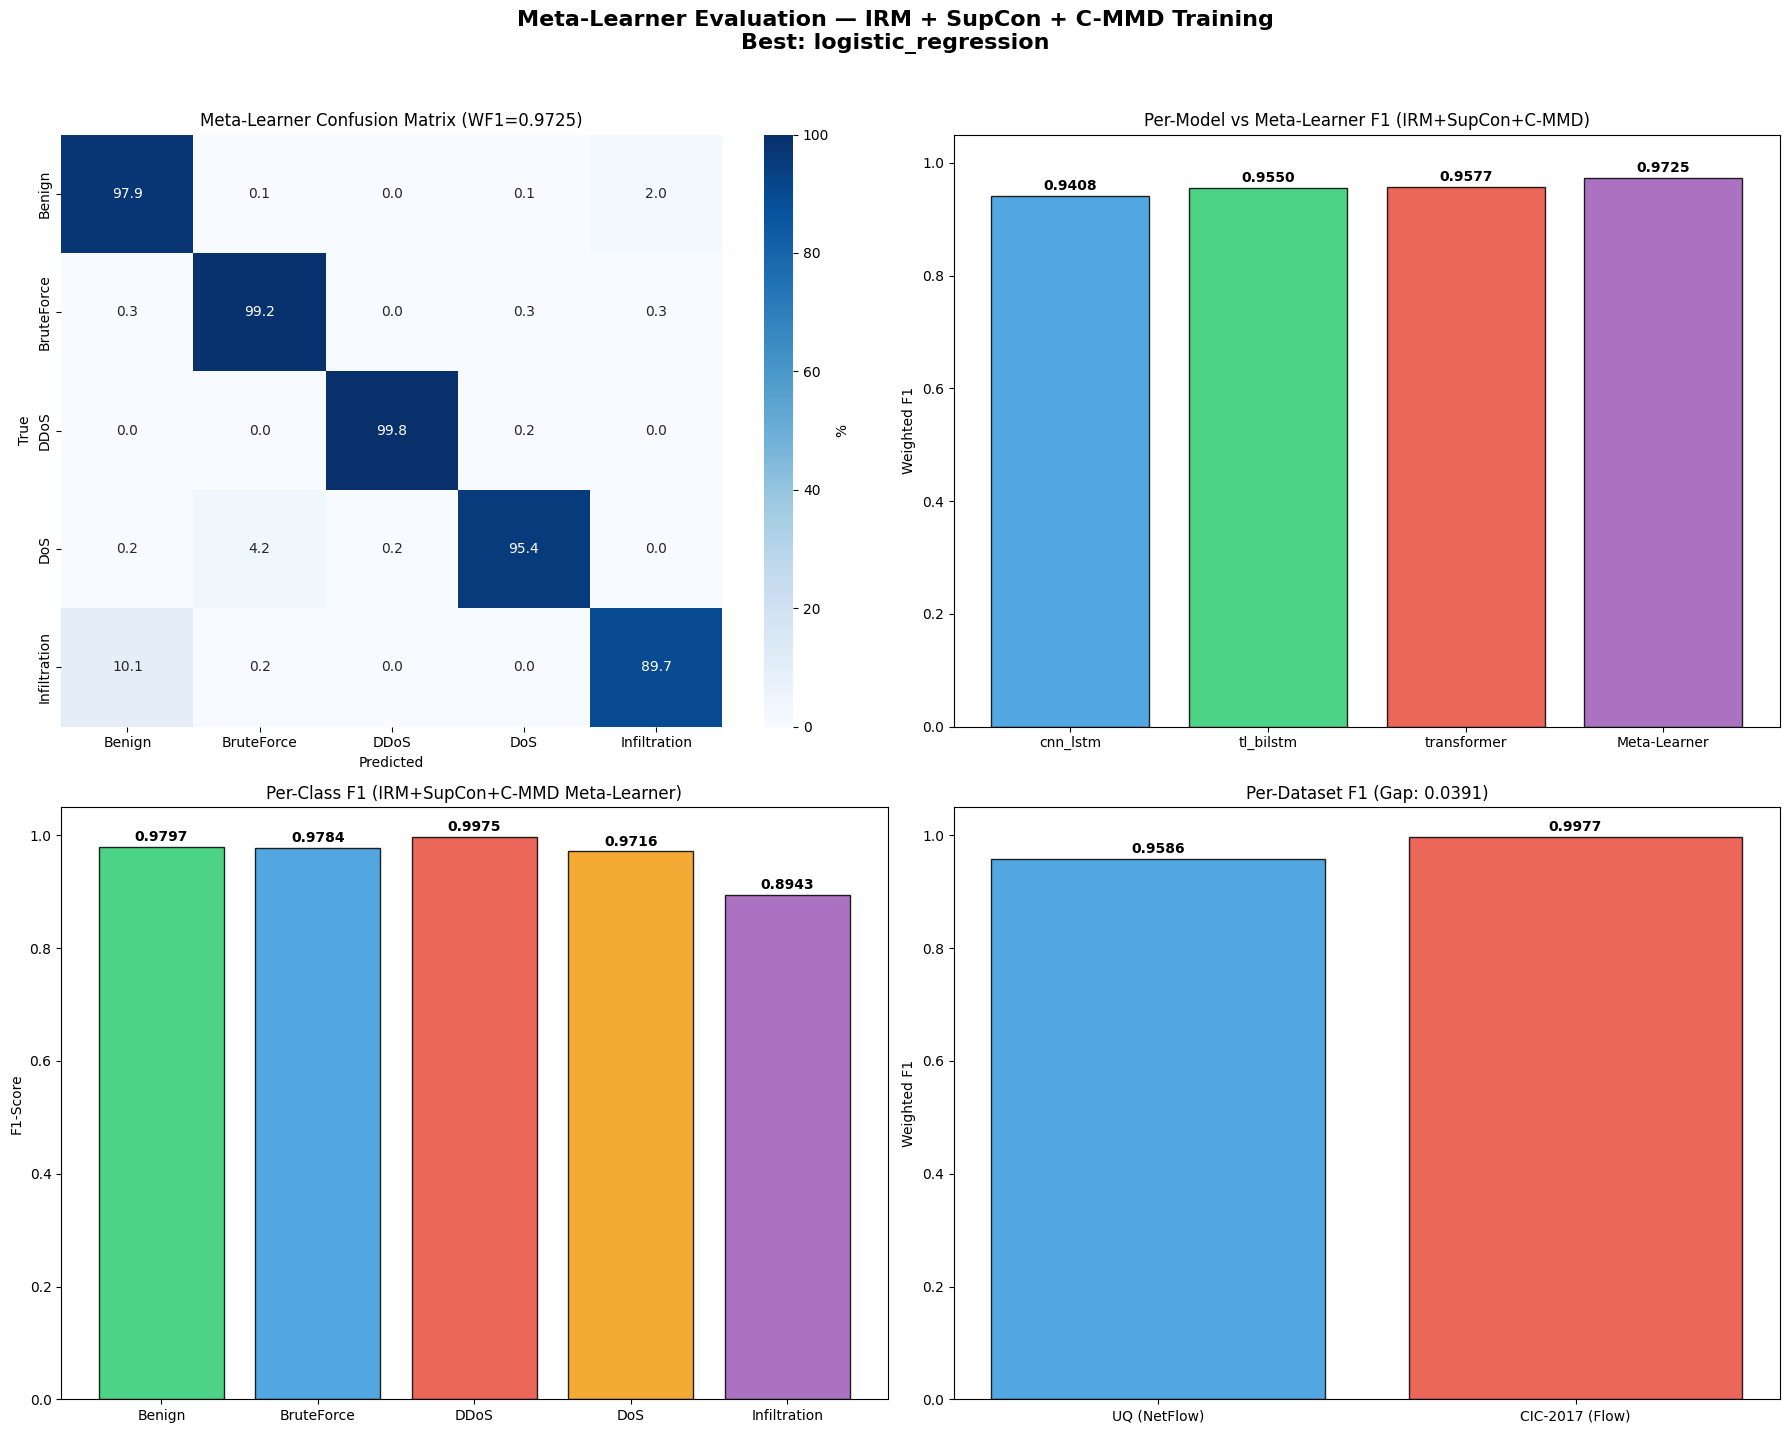

✓ Evaluation dashboard saved.


In [15]:
# ================================================================
# Evaluation Dashboard
# ================================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# (1) Confusion Matrix
ax = axes[0, 0]
cm = confusion_matrix(y_test_meta, final_preds)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=UNIFIED_CLASSES, yticklabels=UNIFIED_CLASSES,
            ax=ax, vmin=0, vmax=100, cbar_kws={'label': '%'})
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'Meta-Learner Confusion Matrix (WF1={lr_f1 if best_meta=="logistic_regression" else nn_f1:.4f})')

# (2) Per-model F1 comparison
ax = axes[0, 1]
model_f1s = []
for i, name in enumerate(MODEL_NAMES):
    preds_i = X_meta[:, i*NUM_CLASSES:(i+1)*NUM_CLASSES].argmax(1)
    f1_i = f1_score(y_meta, preds_i, average='weighted')
    model_f1s.append(f1_i)

meta_f1 = lr_f1 if best_meta == 'logistic_regression' else nn_f1
bars = ax.bar(MODEL_NAMES + ['Meta-Learner'],
              model_f1s + [meta_f1],
              color=['#3498db', '#2ecc71', '#e74c3c', '#9b59b6'],
              edgecolor='black', alpha=0.85)
for bar, val in zip(bars, model_f1s + [meta_f1]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', va='bottom', fontweight='bold')
ax.set_ylabel('Weighted F1')
ax.set_title('Per-Model vs Meta-Learner F1 (IRM+SupCon+C-MMD)')
ax.set_ylim([0, 1.05])

# (3) Per-class F1
ax = axes[1, 0]
per_class_f1 = f1_score(y_test_meta, final_preds, average=None, labels=range(NUM_CLASSES))
bars = ax.bar(UNIFIED_CLASSES, per_class_f1,
              color=['#2ecc71', '#3498db', '#e74c3c', '#f39c12', '#9b59b6'],
              edgecolor='black', alpha=0.85)
for bar, val in zip(bars, per_class_f1):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', va='bottom', fontweight='bold')
ax.set_ylabel('F1-Score')
ax.set_title('Per-Class F1 (IRM+SupCon+C-MMD Meta-Learner)')
ax.set_ylim([0, 1.05])

# (4) UQ vs CIC breakdown
ax = axes[1, 1]
uq_mask = origin_test == 'uq'
cic_mask = origin_test == 'cic'
uq_f1 = f1_score(y_test_meta[uq_mask], final_preds[uq_mask], average='weighted')
cic_f1 = f1_score(y_test_meta[cic_mask], final_preds[cic_mask], average='weighted')
bars = ax.bar(['UQ (NetFlow)', 'CIC-2017 (Flow)'], [uq_f1, cic_f1],
              color=['#3498db', '#e74c3c'], edgecolor='black', alpha=0.85)
for bar, val in zip(bars, [uq_f1, cic_f1]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', va='bottom', fontweight='bold')
ax.set_ylabel('Weighted F1')
ax.set_title(f'Per-Dataset F1 (Gap: {abs(uq_f1 - cic_f1):.4f})')
ax.set_ylim([0, 1.05])

plt.suptitle('Meta-Learner Evaluation — IRM + SupCon + C-MMD Training\n'
             f'Best: {best_meta}',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'meta_learner_results.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Evaluation dashboard saved.")

## 8. Train Final Models on Full Data & Save

Train 3 base models trên TOÀN BỘ data (UQ + CIC) với IRM + SupCon + C-MMD → lưu vào `Model_2017_IRM/`.  
Các models này sẽ được dùng bởi Test_Cross_validation notebooks (frozen pipeline).

In [16]:
%%time
# ================================================================
# Train Final Base Models on ALL Data (IRM + SupCon + C-MMD)
# ================================================================
print("Training final base models on full dataset with IRM + SupCon + C-MMD...")

final_models = {}

for model_name in MODEL_NAMES:
    print(f"\n{'='*50}")
    print(f"Training FINAL {model_name} (IRM + SupCon + C-MMD)")
    print(f"{'='*50}")

    # Create fresh model
    models = create_models(uq_n_feat, cic_n_feat)
    model = models[model_name]

    # 90% train, 10% val from full dataset
    uq_tr, uq_vl, uq_yr, uq_yv = train_test_split(
        uq_windows, uq_labels, test_size=0.1,
        random_state=42, stratify=uq_labels)
    cic_tr, cic_vl, cic_yr, cic_yv = train_test_split(
        cic_windows, cic_labels, test_size=0.1,
        random_state=42, stratify=cic_labels)

    model, val_loss, hist = train_base_model_irm(
        model, uq_tr, uq_yr, cic_tr, cic_yr,
        uq_vl, uq_yv, cic_vl, cic_yv,
        epochs=BASE_EPOCHS,
        lr=1e-3,
        batch_size=BATCH_SIZE,
        lambda_irm_max=LAMBDA_IRM_MAX,
        lambda_mmd=LAMBDA_MMD,
        lambda_supcon=LAMBDA_SUPCON,
        lambda_cmmd=LAMBDA_CMMD,
        supcon_temperature=SUPCON_TEMPERATURE,
        warmup_epochs=WARMUP_EPOCHS,
        mmd_subsample=MMD_SUBSAMPLE,
        patience=PATIENCE,
        verbose=True,
    )
    print(f"  Final {model_name} val loss: {val_loss:.4f}")

    # Save
    save_path = os.path.join(MODEL_DIR, f'final_{model_name}.pth')
    torch.save(model.state_dict(), save_path)
    print(f"  Saved: {save_path}")

    final_models[model_name] = model
    del models
    torch.cuda.empty_cache()

print(f"\n{'='*50}")
print("✓ All final models saved (IRM + SupCon + C-MMD)!")
print(f"{'='*50}")

Training final base models on full dataset with IRM + SupCon + C-MMD...

Training FINAL cnn_lstm (IRM + SupCon + C-MMD)


  Epoch   5 | CE: 0.0856 | IRM: 0.0000 | SC: 0.5299 | CMMD: 0.0177 | Val: 0.1409 | λ_irm: 0.00 | P: 0/5
  Epoch  10 | CE: 0.0745 | IRM: 0.0006 | SC: 0.5264 | CMMD: 0.0065 | Val: 0.2949 | λ_irm: 0.89 | P: 2/5
  Epoch  15 | CE: 0.0721 | IRM: 0.0012 | SC: 0.5243 | CMMD: 0.0028 | Val: 0.1243 | λ_irm: 2.00 | P: 1/5
  Epoch  20 | CE: 0.0638 | IRM: 0.0013 | SC: 0.5218 | CMMD: 0.0015 | Val: 0.1018 | λ_irm: 3.11 | P: 1/5
  Epoch  25 | CE: 0.0583 | IRM: 0.0014 | SC: 0.5204 | CMMD: 0.0011 | Val: 0.0912 | λ_irm: 4.22 | P: 2/5
  Epoch  28 | CE: 0.0556 | IRM: 0.0014 | SC: 0.5198 | CMMD: 0.0009 | Val: 0.1089 | λ_irm: 4.89 | P: 5/5
  Early stopping at epoch 28
  Final cnn_lstm val loss: 0.0883
  Saved: ../Project/Model/Model_IRM/final_cnn_lstm.pth

Training FINAL tl_bilstm (IRM + SupCon + C-MMD)
  Epoch   5 | CE: 0.0767 | IRM: 0.0000 | SC: 0.5290 | CMMD: 0.0220 | Val: 0.0904 | λ_irm: 0.00 | P: 0/5
  Epoch  10 | CE: 0.0691 | IRM: 0.0004 | SC: 0.5265 | CMMD: 0.0177 | Val: 0.0860 | λ_irm: 0.89 | P: 1/5
 

## 9. Latent Space Analysis — Per-Class Z Separation

**Trước SupCon+C-MMD**: BruteForce/DoS Z vectors nằm trong vùng Benign → model không nhận ra chúng.

**Sau SupCon+C-MMD**: 
- Mỗi class nên tạo cluster riêng (SupCon effect)
- Cluster cùng class từ UQ và CIC nên overlap (C-MMD effect)
- BruteForce/DoS phải tách khỏi Benign

Visualization: t-SNE 2D projection, color by (a) dataset origin, (b) attack class.

t-SNE input: (6000, 64)


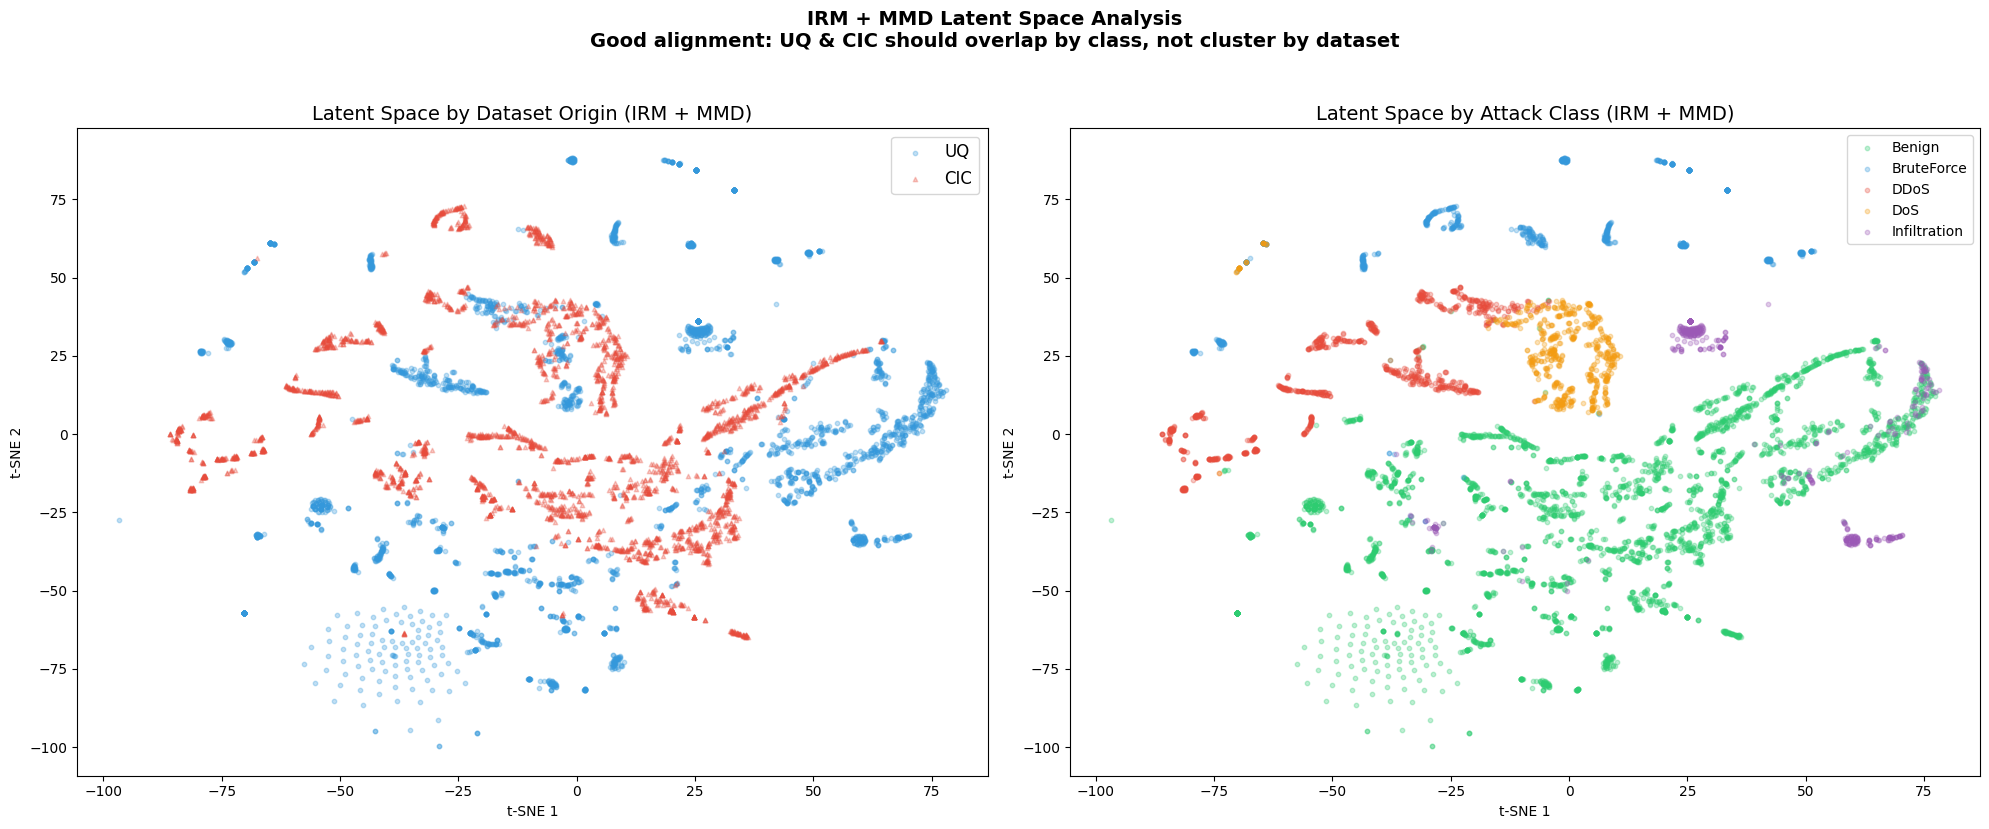

✓ t-SNE visualization saved.
CPU times: user 1min 32s, sys: 65.5 ms, total: 1min 32s
Wall time: 9.34 s


In [17]:
%%time
# ================================================================
# Latent Space Analysis: t-SNE Visualization
# ================================================================
from sklearn.manifold import TSNE

# Use one of the final models to extract latent embeddings
ref_model = final_models['cnn_lstm']
ref_model.eval()

# Sample for t-SNE (max 3000 per dataset)
TSNE_SAMPLE = 3000
np.random.seed(42)
uq_sample_idx = np.random.choice(len(uq_windows), min(TSNE_SAMPLE, len(uq_windows)), replace=False)
cic_sample_idx = np.random.choice(len(cic_windows), min(TSNE_SAMPLE, len(cic_windows)), replace=False)

# Extract latent embeddings Z (batch, 30, 64) → take mean over time → (batch, 64)
@torch.no_grad()
def get_latent_embeddings(model, windows, dataset_type, batch_size=512):
    ds = TimeSeriesDataset(windows, np.zeros(len(windows)), dataset_type)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)
    all_z = []
    for x, _, _ in loader:
        x = x.to(DEVICE)
        z = model.aligner(x, dataset_type)  # (batch, 30, 64)
        z_mean = z.mean(dim=1)  # (batch, 64) — average over time
        all_z.append(z_mean.cpu().numpy())
    return np.vstack(all_z)

z_uq = get_latent_embeddings(ref_model, uq_windows[uq_sample_idx], 'uq')
z_cic = get_latent_embeddings(ref_model, cic_windows[cic_sample_idx], 'cic')

z_all = np.vstack([z_uq, z_cic])
labels_all = np.concatenate([uq_labels[uq_sample_idx], cic_labels[cic_sample_idx]])
origin_all = np.array(['UQ'] * len(z_uq) + ['CIC'] * len(z_cic))

print(f"t-SNE input: {z_all.shape}")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
z_2d = tsne.fit_transform(z_all)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# (a) Color by dataset origin
ax = axes[0]
for origin, color, marker in [('UQ', '#3498db', 'o'), ('CIC', '#e74c3c', '^')]:
    mask = origin_all == origin
    ax.scatter(z_2d[mask, 0], z_2d[mask, 1], c=color, alpha=0.3,
               s=10, marker=marker, label=origin)
ax.legend(fontsize=12)
ax.set_title('Latent Space by Dataset Origin (IRM + MMD)', fontsize=14)
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')

# (b) Color by attack class
ax = axes[1]
class_colors = {'Benign': '#2ecc71', 'BruteForce': '#3498db',
                'DDoS': '#e74c3c', 'DoS': '#f39c12', 'Infiltration': '#9b59b6'}
for cls, color in class_colors.items():
    mask = labels_all == UNIFIED_CLASSES.index(cls)
    ax.scatter(z_2d[mask, 0], z_2d[mask, 1], c=color, alpha=0.3,
               s=10, label=cls)
ax.legend(fontsize=10)
ax.set_title('Latent Space by Attack Class (IRM + MMD)', fontsize=14)
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')

plt.suptitle('IRM + MMD Latent Space Analysis\n'
             'Good alignment: UQ & CIC should overlap by class, not cluster by dataset',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'latent_space_tsne.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ t-SNE visualization saved.")

## 10. Inference Pipeline & Quick Test

Full inference: `raw features → FeatureAligner → 3 Base Models → Meta-Learner → prediction`

Models saved tại `../Project/Model/Model_2017_IRM/` — dùng path này trong các Test_Cross_validation notebooks.

In [18]:
# ================================================================
# Inference Function (same as Meta_Learner.ipynb)
# ================================================================

def predict(windows, dataset_type, final_models, meta_learner, meta_type='lr'):
    """
    Full inference pipeline.

    Args:
        windows: np.ndarray (N, 30, feature_dim)
        dataset_type: 'uq' or 'cic'
        final_models: dict of trained AlignerWithModel
        meta_learner: trained meta-learner
        meta_type: 'lr' or 'nn'

    Returns:
        predictions: np.ndarray (N,)
        class_names: list of str
    """
    probs_list = []
    for name in MODEL_NAMES:
        probs = predict_proba_dataset(final_models[name], windows, dataset_type)
        probs_list.append(probs)

    X_meta_new = np.hstack(probs_list)  # (N, 15)

    if meta_type == 'lr':
        preds = meta_learner.predict(X_meta_new)
    else:
        with torch.no_grad():
            logits = meta_learner(torch.FloatTensor(X_meta_new).to(DEVICE))
            preds = logits.argmax(1).cpu().numpy()

    class_names = [UNIFIED_CLASSES[p] for p in preds]
    return preds, class_names


# Quick test
print("=== Quick Inference Test (IRM Models) ===")
meta = lr_meta if best_meta == 'logistic_regression' else dense_meta
meta_t = 'lr' if best_meta == 'logistic_regression' else 'nn'

# Test on UQ
preds_uq, names_uq = predict(uq_windows[:10], 'uq', final_models, meta, meta_t)
print(f"UQ  Predictions: {names_uq}")
print(f"UQ  True labels: {[UNIFIED_CLASSES[l] for l in uq_labels[:10]]}")

# Test on CIC
preds_cic, names_cic = predict(cic_windows[:10], 'cic', final_models, meta, meta_t)
print(f"CIC Predictions: {names_cic}")
print(f"CIC True labels: {[UNIFIED_CLASSES[l] for l in cic_labels[:10]]}")

# Final summary
print(f"\n{'='*60}")
print(f"  IRM + MMD TRAINING COMPLETE")
print(f"{'='*60}")
print(f"\nModels saved to: {MODEL_DIR}/")
print(f"  - final_cnn_lstm.pth")
print(f"  - final_tl_bilstm.pth")
print(f"  - final_transformer.pth")
print(f"  - meta_learner_lr.pkl / meta_learner_nn.pth")
print(f"  - meta_dataset.npz")
print(f"  - irm_training_diagnostics.png")
print(f"  - meta_learner_results.png")
print(f"  - latent_space_tsne.png")
print(f"\nNext step: Run Test_Cross_validation notebooks with")
print(f"  MODEL_DIR = '{MODEL_DIR}'")
print(f"  to verify zero-shot transfer improvement.")

=== Quick Inference Test (IRM Models) ===
UQ  Predictions: ['Benign', 'Benign', 'Benign', 'Benign', 'Benign', 'Benign', 'Benign', 'Benign', 'Benign', 'Benign']
UQ  True labels: ['Benign', 'Benign', 'Benign', 'Benign', 'Benign', 'Benign', 'Benign', 'Benign', 'Benign', 'Benign']
CIC Predictions: ['Benign', 'Benign', 'Benign', 'Benign', 'Benign', 'Benign', 'Benign', 'Benign', 'Benign', 'Benign']
CIC True labels: ['Benign', 'Benign', 'Benign', 'Benign', 'Benign', 'Benign', 'Benign', 'Benign', 'Benign', 'Benign']

  IRM + MMD TRAINING COMPLETE

Models saved to: ../Project/Model/Model_IRM/
  - final_cnn_lstm.pth
  - final_tl_bilstm.pth
  - final_transformer.pth
  - meta_learner_lr.pkl / meta_learner_nn.pth
  - meta_dataset.npz
  - irm_training_diagnostics.png
  - meta_learner_results.png
  - latent_space_tsne.png

Next step: Run Test_Cross_validation notebooks with
  MODEL_DIR = '../Project/Model/Model_IRM'
  to verify zero-shot transfer improvement.
